In [1]:
from PIL import Image

In [10]:
import processing_utils as util

In [18]:
import torch
import numpy as np
img = Image.open("../CHINA PASSPORT & VISA.jpg").resize((112,112))
img_tensor = torch.from_numpy(np.array(img))
img_tensor = img_tensor.permute(2,0,1).unsqueeze(0)

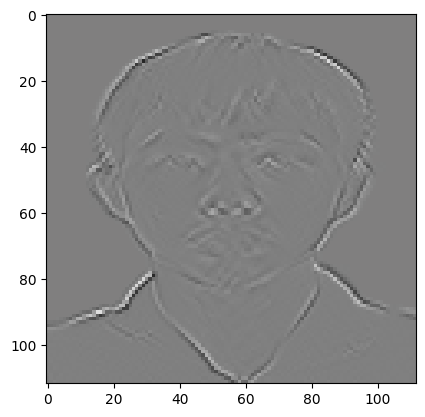

In [45]:
import pylab
freq = util.form_training_batch(img_tensor, [1])[0]
zeros = torch.zeros((1, 192 - 27, 112, 112))
freq = torch.cat([freq, zeros], dim=1)
img_2 = util.idct_transform(freq)[0]
pylab.imshow(img_2.permute(1,2,0).numpy())

In [2]:
import pickle
with open("./log/insight_student_embeddings_val_epoch_final.pkl", "rb") as f:
    id_embs = pickle.load(f)

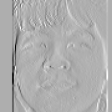

In [6]:
from PIL import Image
t = id_embs["templates"][0][0].mean(0).cpu().numpy()
t = (t - t.min()) / (t.max() - t.min() + 1e-8) 
Image.fromarray((t * 255).astype("uint8")).resize((112,112)) 